## Model Evaluation and Comparison

This notebook evaluates the final optimized transformer model
and compares it with the baseline Logistic Regression model.

Evaluation includes:

• Classification metrics  
• Confusion matrix  
• Model performance comparison

In [2]:
#Imports 
import pandas as pd
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix

#load test data
test_df = pd.read_csv("../data/test.csv")

test_df.head()

,Score,Text,sentiment,label
0,3,"Lipton's Tea & Honey Iced Green Tea, the Black...",neutral,1
1,5,"Its good for you, and taste good. What more ca...",positive,2
2,5,I agree 110% with the other review. This is th...,positive,2
3,1,I really wanted to like this rice as we are av...,negative,0
4,2,"My 5-year-old Australian shepherd, Pete, has p...",negative,0


In [3]:
#Load optimized DistilBERT model

model_path = "../models/distilbert_3class_v2_optimized"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [4]:
#Prediction function

def predict_batch(texts: list) -> np.ndarray:
    """
    Generate predictions in batches to avoid GPU memory overflow.
    """

    predictions = []

    batch_size = 32

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        preds = torch.argmax(outputs.logits, dim=1)

        predictions.extend(preds.cpu().numpy())

    return np.array(predictions)

#Generate Predictions
y_true = test_df["label"].values
y_pred = predict_batch(test_df["Text"].tolist())

              precision    recall  f1-score   support

           0       0.84      0.85      0.84      8528
           1       0.77      0.77      0.77      8528
           2       0.89      0.88      0.89      8528

    accuracy                           0.83     25584
   macro avg       0.83      0.83      0.83     25584
weighted avg       0.83      0.83      0.83     25584



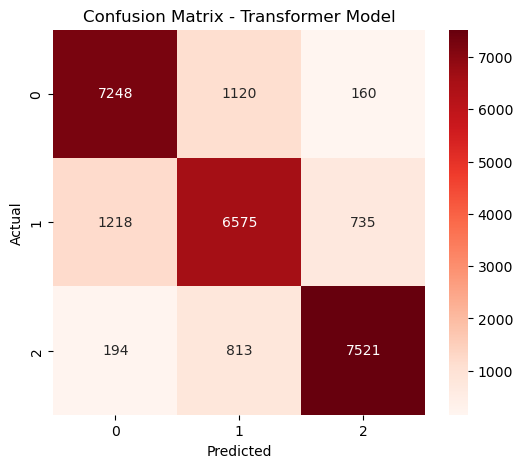

In [5]:
#Evaluation & Confusion Matrix

#Preint classification report
print(classification_report(y_true, y_pred))

#Cofusion matrix - Optimized DistilBERT model
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix - Transformer Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Confuion_Matrix_Optimized_Transfomer_Model")
plt.show()

In [6]:
#Neutral Class Analysis

y_pred = np.array(y_pred)

neutral_index = 1

neutral_mask = y_true == neutral_index

neutral_total = neutral_mask.sum()
neutral_correct = (y_pred[neutral_mask] == neutral_index).sum()

print("Neutral samples:", neutral_total)
print("Correctly predicted:", neutral_correct)
print("Neutral accuracy:", neutral_correct / neutral_total)

Neutral samples: 8528
Correctly predicted: 6575
Neutral accuracy: 0.7709896810506567


In [7]:
#Misclassified Examples

misclassified = test_df[y_true != y_pred]

misclassified.head(10)

,Score,Text,sentiment,label
6,3,I really wanted this formula to work for my so...,neutral,1
8,3,"As it turns out, Wu-Long Tea is bursting with ...",neutral,1
9,3,This is the same stuff you can buy at the big ...,neutral,1
34,2,Well wanted to make sure friend got some Peppe...,negative,0
54,3,I have never tried any of the Shake N Bake pro...,neutral,1
59,2,"These were on sale at Petco, so we gave them a...",negative,0
72,5,Honey Maid graham crackers are naturally good ...,positive,2
75,2,The drinks are excellent although I just got t...,negative,0
80,5,bought these to change up flavors the store no...,positive,2
90,4,These chips are very very good. The flavoring ...,positive,2


In [8]:
#Example Predictions

sample_reviews = test_df.sample(5)

predictions = predict_batch(sample_reviews["Text"].tolist())

for text, true_label, pred_label in zip(sample_reviews["Text"], sample_reviews["label"], predictions):

    print("Review:")
    print(text[:200], "...")
    print("True label:", true_label)
    print("Predicted:", pred_label)
    print("-" * 50)

Review:
I couldn't believe I found the traditional glass jar! I grew up in Mexico, and a few years back, Coronado switched to squeezable bottles. Unfortunately, this means they also thinned the cajeta out to  ...
True label: 2
Predicted: 2
--------------------------------------------------
Review:
Tea was very fragrant with strong smell of chocolate and mint. Could not have been more pleased. ...
True label: 2
Predicted: 1
--------------------------------------------------
Review:
There are a lot of mixed reviews for this soup, but I'm pretty much in love with it. The flavor is unlike any other miso soup I have had and the noodles are perfect. I like to eat this slowly and savo ...
True label: 2
Predicted: 2
--------------------------------------------------
Review:
If you like the flavor of green tea and like your beverage iced you will enjoy this beverage.<br /><br />I like the taste of green tea and I also like the health benefits of green tea.  I mix this wit ...
True label: 2
Pred

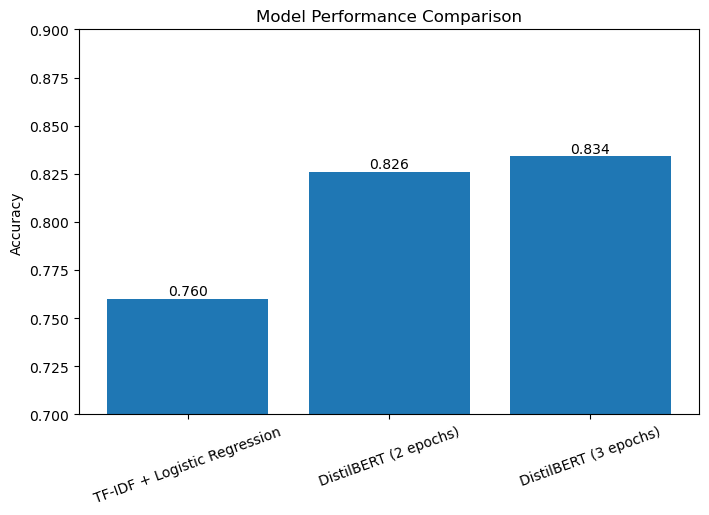

In [9]:
#Model Comparison Chart

models = [
    "TF-IDF + Logistic Regression",
    "DistilBERT (2 epochs)",
    "DistilBERT (3 epochs)"
]

accuracy = [0.76, 0.826, 0.834]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.ylim(0.70, 0.90)

plt.xticks(rotation=20)

for i, v in enumerate(accuracy):
    plt.text(i, v + 0.002, f"{v:.3f}", ha="center")
plt.savefig("Model_Performance_Comparison")
plt.show()